# pipekit-train — Bayesian inference (3/3): **BlackJAX** (NUTS)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pipekit/blob/main/docs/notebooks/pipekit_train_blackjax.ipynb)

Last of three examples. Notebooks 1–2 fit a Bayesian linear regression with
NumPyro's own engines (SVI, NUTS). Here we sample the **same NumPyro model**
with a **different sampler library** — [BlackJAX](https://blackjax-devs.github.io/blackjax/).

| # | Notebook | Backend | Engine |
|---|----------|---------|--------|
| 1 | `pipekit_train_numpyro_svi` | `numpyro-svi` | NumPyro SVI |
| 2 | `pipekit_train_numpyro_mcmc` | `numpyro-mcmc` | NumPyro NUTS |
| **3** | **this one** | `blackjax` | **BlackJAX NUTS** |

**Why a separate backend?** NumPyro is a *probabilistic programming language*
(a modelling DSL **plus** built-in engines). **BlackJAX is a sampler library,
not a PPL** — it operates on a bare `logdensity_fn(position) -> float`. The
`blackjax` backend bridges a `NumpyroTask` to a log-density (via
`numpyro.infer.util.initialize_model`) and reuses the **shared `bayes`
seam**, so the same model swaps engines by flipping the backend string. It
also fits the per-step loop more naturally: BlackJAX exposes
`kernel.step(rng, state) -> (state, info)` — **one sample per step**. See
[`blackjax_adapter.md`](../design-train/blackjax_adapter.md) (ADR **D14**).

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pipekit-train[blackjax] @ git+https://github.com/jejjohnson/pipekit@main#subdirectory=packages/pipekit-train",
            "pipekit @ git+https://github.com/jejjohnson/pipekit@main#subdirectory=packages/pipekit",
        ],
        check=True,
    )

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from pipekit import Identity
from pipekit_train import IterableDataset, JSONLWriter, TrainingLoop
from pipekit_train.adapters.bayes import NumpyroTask
from pipekit_train.adapters.blackjax import BlackjaxTask

/home/user/pipekit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Reproducibility readout — version metadata for the committed outputs.
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p numpy,jax,blackjax,numpyro,pipekit,pipekit_train",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.10.0

numpy        : 2.4.4
jax          : 0.10.1
blackjax     : 1.5
numpyro      : 0.21.0
pipekit      : 0.0.1
pipekit_train: 0.0.1

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.18.5
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## 1. The problem & model

Identical model to notebooks 1–2: priors $w \sim \mathcal{N}(0,5)$, $b \sim
\mathcal{N}(0,5)$, $\sigma \sim \mathrm{HalfNormal}(1)$, Gaussian likelihood
$y_i \sim \mathcal{N}(w x_i + b, \sigma^2)$, data from $y = 2x + 1$.

In [4]:
rng = np.random.default_rng(0)
n = 128
xs = rng.uniform(-1.0, 1.0, size=(n, 1)).astype(np.float32)
ys = (2.0 * xs[:, 0] + 1.0 + 0.1 * rng.standard_normal(n)).astype(np.float32)

pairs = list(zip(xs, ys, strict=True))
dataset = IterableDataset(source=pairs, content_hash=f"linreg-{n}")


def model(x, y=None):
    w = numpyro.sample("w", dist.Normal(0.0, 5.0))
    b = numpyro.sample("b", dist.Normal(0.0, 5.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = w * x[..., 0] + b
    numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)

## 2. The inference method — BlackJAX NUTS on a bridged log-density

BlackJAX samples a target $\pi(\theta) \propto \exp(\ell(\theta))$ known only
through its (unnormalised) log-density $\ell$. The bridge turns our NumPyro
model into exactly that: `initialize_model` returns the model's
**potential function** $U(z) = -\log \tilde p(z \mid \mathbf{x}, \mathbf{y})$
over *unconstrained* parameters $z$, and a **constrain map**
`postprocess_fn` back to the model's sites. The seam builds

$$
\ell(z) = -U(z), \qquad
\theta = \text{constrain}(z),
$$

then runs NUTS like notebook 2 — Hamiltonian dynamics on $H(z, p) =
-\ell(z) + \tfrac12 p^\top M^{-1} p$ — but each transition is one explicit
`kernel.step`. A **`window_adaptation`** warmup tunes the step size and mass
matrix $M$; then the per-step loop records one draw per step, streaming
acceptance / divergence diagnostics to the metric writer. The unconstrained
draws $\{z^{(s)}\}$ are mapped through the constrain map to $\{\theta^{(s)}\}$
before the posterior predictive — essential for the transformed
`HalfNormal` scale $\sigma$.

## 3. Fit through the `TrainingLoop`

A `BlackjaxTask` wraps the `NumpyroTask` (the bridge source) and selects the
sampler. `max_steps` is the number of posterior draws; `num_warmup` is the
`window_adaptation` budget. We attach a `JSONLWriter` to capture the
per-step diagnostics that BlackJAX — unlike NumPyro's single blocking
`mcmc.run` — exposes.

In [5]:
writer = JSONLWriter(path="blackjax_metrics.jsonl", flush_every=1)

loop = TrainingLoop(
    model_op=Identity(),  # ignored; the task carries the model
    dataset=dataset,
    backend="blackjax",
    task=BlackjaxTask(
        numpyro_task=NumpyroTask(model, predictive_site="obs"),
        sampler="nuts",
        num_warmup=400,
    ),
    max_steps=500,  # = posterior draws
    metric_writer=writer,
    log_every_n_steps=1,
    seed=0,
)

The per-step `kernel.step` is JIT-compiled once (calling it un-jitted in a
Python loop would re-trace every iteration). The first step pays the compile;
the rest are fast.

In [6]:
bj_op, artifact = loop.run()

info = artifact.backend_info
print(f"Backend      : {info['backend']}")
print(f"Sampler      : {info['sampler']}")
print(f"Warmup/draws : {info['num_warmup']} / {info['num_samples']}")
print(f"Divergences  : {info['num_divergences']}")
print(f"BlackJAX ver : {info['blackjax_version']}")

Backend      : blackjax
Sampler      : nuts
Warmup/draws : 400 / 500
Divergences  : 0
BlackJAX ver : 1.5


## 4. Per-step diagnostics

Because each draw is a loop step, the writer logged the **acceptance rate**
and **divergence flag** per sample — diagnostics a single blocking sampler
can only report in aggregate.

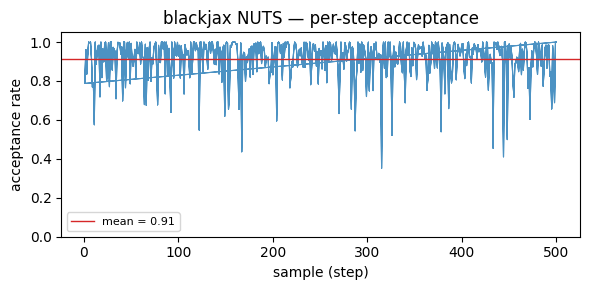

In [7]:
import json


with open("blackjax_metrics.jsonl") as f:
    records = [json.loads(line) for line in f]
steps = [r["step"] for r in records]
accept = [r["metrics"]["acceptance_rate"] for r in records]

plt.figure(figsize=(6, 3))
plt.plot(steps, accept, lw=0.8, alpha=0.8)
plt.axhline(np.mean(accept), color="C3", lw=1, label=f"mean = {np.mean(accept):.2f}")
plt.xlabel("sample (step)")
plt.ylabel("acceptance rate")
plt.ylim(0, 1.05)
plt.legend(fontsize=8)
plt.title("blackjax NUTS — per-step acceptance")
plt.tight_layout()
plt.show()

## 5. Posterior & predictive

The bridged NUTS path constrains the samples back to the model's sites, so
`bj_op.posterior` holds draws of $\{w, b, \sigma\}$ — directly comparable to
notebook 2's NumPyro-NUTS posterior (same model, different engine).

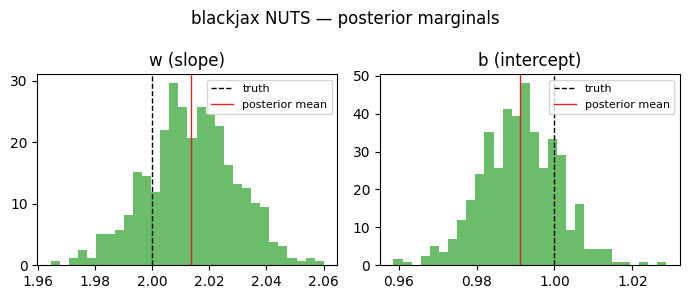

w: 2.014 ± 0.016   (truth 2.0)
b: 0.991 ± 0.010   (truth 1.0)


In [8]:
post = bj_op.posterior
w_s = np.asarray(post["w"])
b_s = np.asarray(post["b"])

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, samples, truth, name in (
    (axes[0], w_s, 2.0, "w (slope)"),
    (axes[1], b_s, 1.0, "b (intercept)"),
):
    ax.hist(samples, bins=30, color="C2", alpha=0.7, density=True)
    ax.axvline(truth, color="k", ls="--", lw=1, label="truth")
    ax.axvline(samples.mean(), color="C3", lw=1, label="posterior mean")
    ax.set_title(name)
    ax.legend(fontsize=8)
fig.suptitle("blackjax NUTS — posterior marginals")
fig.tight_layout()
plt.show()

print(f"w: {w_s.mean():.3f} ± {w_s.std():.3f}   (truth 2.0)")
print(f"b: {b_s.mean():.3f} ± {b_s.std():.3f}   (truth 1.0)")

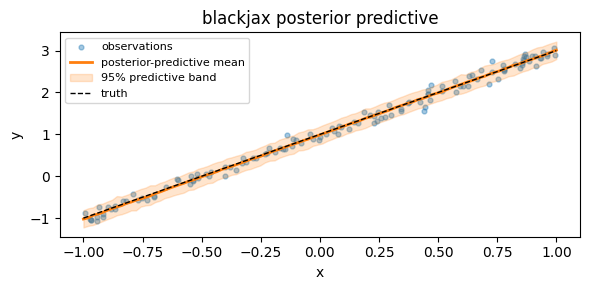

In [9]:
x_grid = jnp.linspace(-1.0, 1.0, 100).reshape(-1, 1)
y_mean = np.asarray(bj_op(x_grid))
draws = bj_op.predictive(jax.random.key(1), x_grid)["obs"]
lo, hi = np.percentile(np.asarray(draws), [2.5, 97.5], axis=0)

plt.figure(figsize=(6, 3))
plt.scatter(xs[:, 0], ys, s=12, alpha=0.4, label="observations")
plt.plot(x_grid[:, 0], y_mean, "C1", lw=2, label="posterior-predictive mean")
plt.fill_between(
    x_grid[:, 0], lo, hi, color="C1", alpha=0.2, label="95% predictive band"
)
plt.plot([-1, 1], [-1, 3], "k--", lw=1, label="truth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(fontsize=8)
plt.title("blackjax posterior predictive")
plt.tight_layout()
plt.show()

## 6. The artifact

The trained operator is the *same* `NumpyroPredictiveOp` the NumPyro
adapters return (the shared `bayes` seam) — its weight blob is the
constrained posterior-samples PyTree, round-tripping through the model
registry like any other trained model.

In [10]:
sites = {k: tuple(np.shape(v)) for k, v in bj_op.posterior.items()}
print("Posterior sites:", sites)
print("Weight-blob bytes:", len(bj_op.serialize_weights()))

# Both the experiment-backed and the local fallback artifact are dataclasses,
# so `dataclasses.asdict` serialises either; `pipekit-train[experiment]` adds
# native `artifact.save(...)` + model-registry integration on top.
import dataclasses
import json


with open("blackjax_artifact.json", "w") as f:
    json.dump(dataclasses.asdict(artifact), f, indent=2, default=str)
print("Saved blackjax_artifact.json — the run is reproducible.")

Posterior sites: {'b': (500,), 'sigma': (500,), 'w': (500,)}
Weight-blob bytes: 6188
Saved blackjax_artifact.json — the run is reproducible.


### Recap — one model, three engines

Across the three notebooks the **model never changed** — only the backend:

- `numpyro-svi` — fast variational approximation (per-step optimiser).
- `numpyro-mcmc` — exact NUTS posterior (one blocking run).
- `blackjax` — exact NUTS posterior from a *separate sampler library*, with
  per-step diagnostics, via the shared model→log-density bridge.

All three return an ordinary `pipekit.Operator` + `TrainingArtifact` that
compose into inference pipelines and round-trip through the model registry.

In [11]:
# Clean up the demo files.
import os


for path in ("blackjax_metrics.jsonl", "blackjax_artifact.json"):
    if os.path.exists(path):
        os.remove(path)